
Processing Oligodendrocytes


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifie

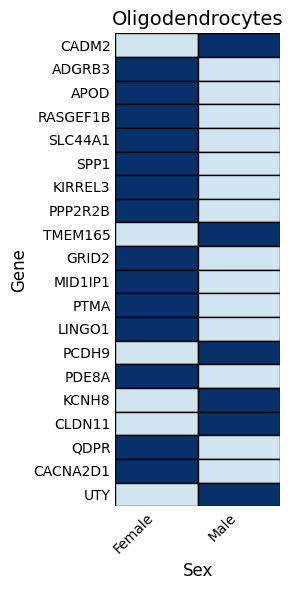

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure9/Oli_gene_SHAP_sex_heatmap.png

Processing OPCs


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifie

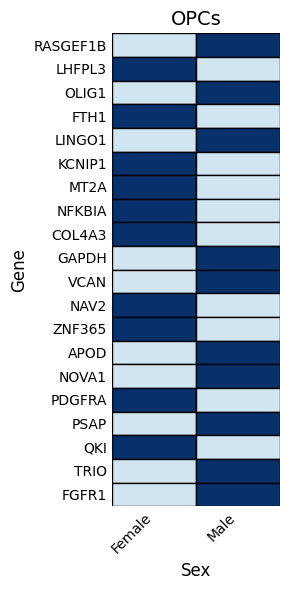

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure9/Opc_gene_SHAP_sex_heatmap.png


In [1]:
from pathlib import Path
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# Paths
# =========================================================
base_dir = Path("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new")
expr_path = "/home/adm808/NormalizedCellMatrixSyn18485175.parquet"
metadata_path = "/home/adm808/New_CellMetadataSyn1848517.parquet"

output_dir = Path(
    "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure9/"
)
output_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# Cell types
# =========================================================
cell_types = {
    # "Ast": "Astrocytes",
    # "Ex": "Excitatory Neurons",
    # "In": "Inhibitory Neurons",
    # "Mic": "Microglia",
    "Oli": "Oligodendrocytes",
    "Opc": "OPCs"
}
# Other four were run already

# =========================================================
# Color mapping (UNCHANGED)
# =========================================================
rank_colors = {
    "max": "#08306b",
    "mid": "#67a9cf",
    "min": "#d1e5f0",
    "zero": "#ffffff"
}

# =========================================================
# Load data
# =========================================================
expr = pd.read_parquet(expr_path).T
expr.columns = expr.columns.str.replace(r'[^a-zA-Z0-9]', '', regex=True)

metadata = pd.read_parquet(metadata_path)
metadata = metadata.set_index("TAG")

common_tags = expr.index.intersection(metadata.index)
X_full = expr.loc[common_tags]
meta = metadata.loc[common_tags]

# =========================================================
# Main loop
# =========================================================
for ct_key, ct_name in cell_types.items():
    print(f"\nProcessing {ct_name}")

    shap_by_sex = {"Female": [], "Male": []}

    for split in range(1, 6):
        model_path = base_dir / ct_key / f"split_{split}" / "maximal_classifier.joblib"
        if not model_path.exists():
            continue

        automl_model = joblib.load(model_path)
        booster = automl_model.model.model.booster_
        features = automl_model.feature_names_in_

        gene_feats = [f for f in features if f in X_full.columns]

        # --- restrict to current cell type ---
        ct_cells = meta.index[meta["broad.cell.type"] == ct_key]
        ct_cells = ct_cells.intersection(X_full.index)

        X = X_full.loc[ct_cells, gene_feats].fillna(0)

        # --- optional but strongly recommended subsampling ---
        if len(X) > 2000:
            X = X.sample(2000, random_state=0)

        explainer = shap.TreeExplainer(booster)
        shap_vals = explainer.shap_values(X)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        shap_df = pd.DataFrame(shap_vals, columns=gene_feats, index=X.index)

        for sex_val, sex_label in [(0, "Female"), (1, "Male")]:
            cells = meta.index[meta["msex"] == sex_val]
            cells = cells.intersection(shap_df.index)

            if len(cells) < 10:
                continue

            mean_shap = shap_df.loc[cells].abs().mean()
            shap_by_sex[sex_label].append(mean_shap)

    # =====================================================
    # Aggregate + plot
    # =====================================================
    if not shap_by_sex["Female"] or not shap_by_sex["Male"]:
        print(f"Skipping {ct_name} — insufficient data")
        continue

    female_mean = pd.concat(shap_by_sex["Female"], axis=1).mean(axis=1)
    male_mean   = pd.concat(shap_by_sex["Male"], axis=1).mean(axis=1)

    pivot = pd.DataFrame({
        "Female": female_mean,
        "Male": male_mean
    })

    pivot = pivot[(pivot > 0).any(axis=1)]
    pivot = pivot.loc[pivot.mean(axis=1).nlargest(20).index]
    pivot = pivot.sort_values(by="Female", ascending=False)

    # =====================================================
    # Color matrix (IDENTICAL logic)
    # =====================================================
    color_matrix = []
    for _, row in pivot.iterrows():
        vals = row.values
        row_colors = []
        if all(np.isclose(v, 0.0) for v in vals):
            row_colors = [rank_colors["zero"]] * len(vals)
        else:
            max_v = max(vals)
            min_v = min([v for v in vals if not np.isclose(v, 0.0)])
            for v in vals:
                if np.isclose(v, 0.0):
                    row_colors.append(rank_colors["zero"])
                elif np.isclose(v, max_v):
                    row_colors.append(rank_colors["max"])
                elif np.isclose(v, min_v):
                    row_colors.append(rank_colors["min"])
                else:
                    row_colors.append(rank_colors["mid"])
        color_matrix.append(row_colors)

    color_matrix = np.array(color_matrix)

    # =====================================================
    # Plot
    # =====================================================
    fig, ax = plt.subplots(figsize=(3, 6))
    nrows, ncols = pivot.shape

    for y in range(nrows):
        for x in range(ncols):
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1,
                facecolor=color_matrix[y, x],
                edgecolor="black",
                linewidth=1.0
            ))

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.invert_yaxis()

    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticklabels(pivot.index)

    ax.set_title(ct_name, fontsize=14)
    ax.set_xlabel("Sex", fontsize=12)
    ax.set_ylabel("Gene", fontsize=12)

    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    save_path = output_dir / f"{ct_key}_gene_SHAP_sex_heatmap.png"
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved: {save_path}")